# Cost Function

In [2]:
# requirements
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

We cannot use the same cost function that we use for linear regression because the Logistic Function will cause the output to be wavy, causing many local optima. In other words, it will not be a convex function.

Instead, our cost function for logistic regression looks like:

$$
J(\theta) = \frac{1}{m} \sum_{i = 1}^m  \text{cost}(h_\theta(x^{(i)}),y^{(i)}),
$$

where

$$
\text{cost}(h_\theta(x),y) = -\log(h_\theta(x)) \quad \text{if} \quad y = 1
$$

$$
\text{cost}(h_\theta(x),y) = -\log(1 - h_\theta(x)) \quad \text{if} \quad y = 0
$$

When $y = 1$, we get the following plot for $J(\theta)$ vs. $h_\theta (x)$, we get the following plot

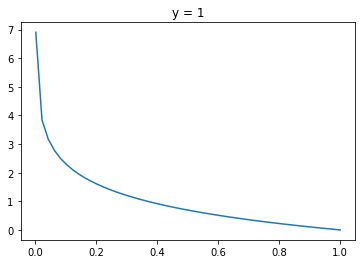

In [3]:
h = np.linspace(1e-3, 1, 50)
J = -np.log(h)

plt.plot(h, J)
plt.title('y = 1')
plt.show()

When $y = 0$, we get the following plot for $J(\theta)$ vs. $h_\theta (x)$, we get the following plot

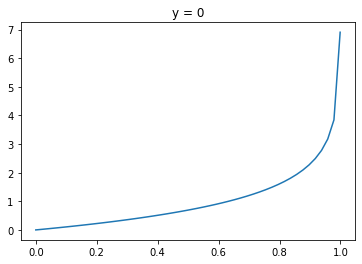

In [4]:
h = np.linspace(0, 0.999, 50)
J = -np.log(1-h)

plt.plot(h, J)
plt.title('y = 0')
plt.show()

$$
\text{cost}(h_\theta(x),y) = 0 \quad \text{if} \quad h_\theta(x) = y
$$

$$
\text{cost}(h_\theta(x),y) \to \infty \quad \text{if} \quad y = 0 \quad \text{and} \quad h_\theta(x) \to 1
$$

$$
\text{cost}(h_\theta(x),y) \to \infty \quad \text{if} \quad y = 1 \quad \text{and} \quad h_\theta(x) \to 0
$$

If our correct answer $y$ is 0, then the cost function will be 0 if our hypothesis function also outputs 0. If our hypothesis approaches 1, then the cost function will approach infinity.

If our correct answer $y$ is 1, then the cost function will be 0 if our hypothesis function outputs 1. If our hypothesis approaches 0, then the cost function will approach infinity.

Note that writing the cost function in this way guarantees that $J(\theta)$ is convex for logistic regression.

We can compress our cost function's two conditional cases into one case:

$$
\text{cost}(h_\theta(x),y) = -\log(h_\theta(x)) - (1-y)\log(1 - h_\theta(x))
$$

Notice that when $y$ is equal to 1, then the second term $(1-y)\log(1-h_\theta(x))$ will be zero and will not affect the result. If y is equal to 0, then the first term $-y \log(h_\theta(x))$ will be zero and will not affect the result.

We can fully write out our entire cost function as follows:

$$
J(\theta) = -\frac{1}{m} \sum_{i = 1}^m \left[ y^{(i)} \log(h_\theta(x^{(i)})) + (1 - y^{(i)})\log(1-h_\theta(x^{(i)})) \right]
$$

A vectorized implementation is:

$$
h = g(X\theta)
$$

$$
J(\theta) = \frac{1}{m} \left( -y^T \log(h) - (1 - y)^T \log(1 - h)\right)
$$

## Gradient Descent

Remember that the general form of gradient descent is:

repeat{
$$
\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j}J(\theta)
$$
}

We can work out the derivative part using calculus to get:

$$
\theta_j := \theta_j - \frac{\alpha}{m}\sum_{i = 1}^m (h_\theta (x^{(i)}) - y^{(i)})x_j^{(i)}
$$

Notice that this algorithm is identical to the one we used in linear regression. We still have to simultaneously update all values in theta.

A vectorized implementation is:

$$
\theta := \theta - \frac{\alpha}{m} X^T \left(g(\theta X) - \overrightarrow{y}   \right)
$$

# Advanced Optimization

"Conjugate gradient", "BFGS", and "L-BFGS" are more sophisticated, faster ways to optimize $\theta$ that can be used instead of gradient descent. We suggest that you should not write these more sophisticated algorithms yourself (unless you are an expert in numerical computing) but use the libraries instead, as they're already tested and highly optimized

We first need to provide a function that evaluates the following two functions for a given input value $\theta$:

$$
J(\theta)
$$

$$
\frac{\partial}{\partial \theta_j}J(\theta)
$$

Then we can use an avaiable optimization algorithm, some can be found here:

[scipy.optimize](https://docs.scipy.org/doc/scipy/reference/optimize.html)

# Multiclass Classification: One-vs-all

Now we will approach the classification of data when we have more than two categories. Instead of $y = \{0,1\}$ we will expand our definition so that $y = \{0,1...n\}$.

Since $y = \{0,1...n\}$, we divide our problem into $n+1$ (+1 because the index starts at 0) binary classification problems; in each one, we predict the probability that $y$ is a member of one of our classes.

$$
y \in \{0,1...n\}
$$

$$
h_\theta^{(0)}(x) = P(y = 0|x; \theta)
$$

$$
h_\theta^{(1)}(x) = P(y = 1|x; \theta)
$$

$$
h_\theta^{(n)}(x) = P(y = n|x; \theta)
$$

$$
prediction = \max_i(h_\theta^{(i)}(x))
$$

We are basically choosing one class and then lumping all the others into a single second class. We do this repeatedly, applying binary logistic regression to each case, and then use the hypothesis that returned the highest value as our prediction.

Train a logistic regression classifier $h_\theta(x)$ for each class to predict the probability that $y = i$.

To make a prediction on a new $x$, pick the class that maximizes $h_\theta(x)$.